In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris


In [ ]:
# Load the iris dataset from sklearn
iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)
data['target'] = iris.target
print(data.head())



   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [ ]:
X = data.drop('target', axis=1)


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [ ]:
data['cluster'] = kmeans.labels_
print(data[['target', 'cluster']].head(10))


   target  cluster
0       0        1
1       0        1
2       0        1
3       0        1
4       0        1
5       0        1
6       0        1
7       0        1
8       0        1
9       0        1


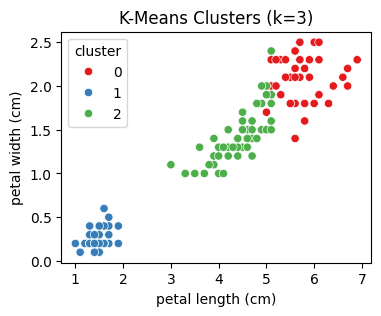

In [ ]:
plt.figure(figsize=(4, 3))
sns.scatterplot(
    x='petal length (cm)',
    y='petal width (cm)',
    hue='cluster',
    data=data,
    palette='Set1'
)
plt.title('K-Means Clusters (k=3)')
plt.show()


In [ ]:
centers = pd.DataFrame(kmeans.cluster_centers_, columns=X.columns)
print(centers)


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0           6.853846          3.076923           5.715385          2.053846
1           5.006000          3.428000           1.462000          0.246000
2           5.883607          2.740984           4.388525          1.434426


In [ ]:
ct = pd.crosstab(data['target'], data['cluster'])
print(ct)


cluster   0   1   2
target             
0         0  50   0
1         3   0  47
2        36   0  14


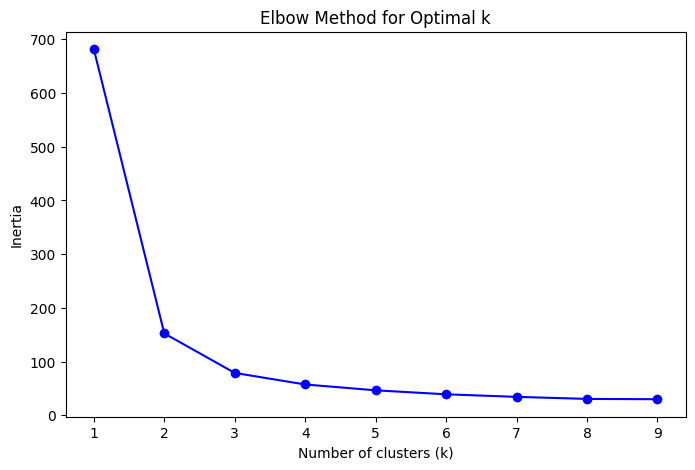

In [ ]:
inertia = []
K_range = range(1, 10)
for k in K_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()
